# 03 · Finding the qubit

Part 2 measured a resonator with one sweep and read a pair of quadratures back. Part 3 keeps the sweeps and changes three other things: what a measurement returns, what a pulse is made of, and how many buses a qubit has.

Four pieces of QProgram arrive with them. A measurement can ask for the classified state instead of the integrated point, and `result.plot` reads that field the same way `result.get` does. A waveform constructor can hold a variable, so one `play` line covers a whole sweep of pulses. A `WaveformLibrary` keeps calibrated numbers outside the program and resolves one name differently on every bus. And `BusSchema.flux_tunable_transmon()` gives each qubit a third line, written with `set_offset` rather than played as a pulse.

Three experiments carry them. Two-tone spectroscopy finds `f01`, a Rabi scan turns it into a pi amplitude, and a flux arc maps `f01` against a DC bias. The first two chain, the fitted `f01` going into the Rabi program and the fitted amplitude into the waveform library of 3.3, and every fit prints its value next to the true one.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.operations import Measure
from qprogram.plotting import DEFAULT_SIZE, LIGHT, Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square

print("numpy", np.__version__, "| scipy", scipy.__version__, "(curve_fit does every fit below)")

numpy 2.5.2 | scipy 1.18.1 (curve_fit does every fit below)


## 3.0 The device

`DEVICE` holds the truth about the simulated chip. The measurement models read it because they stand in for the fridge, and the print statements read it to grade the fits. One number reaches a program, `q0_fr`, and only because Part 2 measured that one already.

`READOUT_PULSE` and `WEIGHTS` are Part 1's objects. Every program below names them as the strings `"readout"` and `"weights"`, and 3.3 is where the names and the objects meet.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit transition at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator (found in Part 2)
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "flux_period": 1.0,  # V, one flux quantum in bias volts
    "flux_offset": 0.05,  # V, where the sweet spot actually sits
}

schema = BusSchema.transmon()
q = schema.q

READOUT_PULSE = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
WEIGHTS = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

print("target to recover: f01 =", DEVICE["q0_f01"] / 1e9, "GHz")
print("then: a_pi =", DEVICE["q0_a_pi"], "and the sweet spot at", DEVICE["flux_offset"], "V")

target to recover: f01 = 4.85 GHz
then: a_pi = 0.62 and the sweet spot at 0.05 V


## 3.1 Two-tone spectroscopy

This scan parks the readout tone where Part 2 put it and sweeps a second tone down the drive line.

In QProgram that is two `set_frequency` calls on two different buses inside one sweep, with a `sync` so the readout waits for the drive to finish. The one thing this program does that neither earlier part did is ask for the classified state alone.

### Asking for the classified state

`fields=` replaces the default tuple `(MF.IQ,)` rather than adding to it, so `fields=(MF.STATE,)` produces `state` and nothing else. Three consequences follow, and every one of them shows up in the cells below.

`result.get(handle)` raises `KeyError`, because its default field is `iq` and this record has none. `field=` is the third positional parameter of both `get` and `plot`, so the array `plot` draws is the array `get` returns.

A `state` array carries no `IQ` dimension, since one classified number per point is all there is. `channels=` is therefore refused outright, all five names of it, and a line figure labels its y axis `State`.

The scatter on such an array is binomial rather than instrumental. `MockMeasurementModel(noise=...)` perturbs the IQ point and leaves the classified outcome alone, so the models here pass `p_excited` and no noise, and 200 shots of an outcome with probability $p$ still carry a standard error of $\sqrt{p(1-p)/N}$, about 0.035 at the top of this peak.

In [4]:
SATURATION = IQPair(
    I=Square(amplitude=0.02, duration=4000),  # 4 us at 2% of full scale: enough to saturate, not to flip
    Q=Square(amplitude=0.0, duration=4000),
)


def p_spec(bus, env):
    """Excited-state population under a long weak drive: a Lorentzian peak at f01, ceiling 0.45."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((env["drive_freq"] - DEVICE["q0_f01"]) / hwhm) ** 2)


print("on resonance :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"]}), 4))
print("2 MHz off    :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 2e6}), 4))
print("20 MHz off   :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 20e6}), 4))

on resonance : 0.45
2 MHz off    : 0.09
20 MHz off   : 0.0011


In [5]:
spec = qp.QProgram(
    label="qubit_spectroscopy",
    description="Two-tone scan for f01 on q0",
    schema=schema,
)
drive_freq = spec.variable("drive_freq", label="Drive frequency", units="Hz")

# 81 points across a 20 MHz window, wide enough to hold a 2 MHz line wherever the design put it.
with spec.average(shots=200):
    with spec.sweep(drive_freq, qp.Linspace(4.840e9, 4.860e9, 81)):
        spec.set_frequency(q[0].readout, DEVICE["q0_fr"])  # park the readout on the resonator
        spec.set_frequency(q[0].drive, drive_freq)  # the tone we are sweeping
        spec.play(q[0].drive, SATURATION)
        spec.sync()  # on hardware, hold the readout until the drive finishes
        m_spec = spec.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print("sweep step:", (4.860e9 - 4.840e9) / 80 / 1e6, "MHz")
print()
print(qp.dumps(spec))

sweep step: 0.25 MHz

#!QProgram 1.0

metadata:
  label: "qubit_spectroscopy"
  description: "Two-tone scan for f01 on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var drive_freq label="Drive frequency" units="Hz"

  average 200:
    for drive_freq in Linspace(start=4840000000.0, stop=4860000000.0, num=81):
      set_frequency q[0].readout 7200000000.0
      set_frequency q[0].drive drive_freq
      play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



`fields=["state"]` sits on the `measure` line of the `.qp` text, so the file records what the experiment asked the hardware to produce. The two pulse names are still strings, because nothing in this scan depends on their shape.

In [6]:
result = qp.simulate(spec, model=qp.MockMeasurementModel(p_excited=p_spec, seed=11))

pop = result.get(m_spec, field=MF.STATE)
print("dims:", pop.dims, "shape:", pop.shape)

try:
    result.get(m_spec)  # the default field is iq, and this record has none
except KeyError as err:
    print("bare get:", err)

try:
    result.plot(m_spec, field=MF.STATE, channels="magnitude")
except qp.ValidationError as exc:
    print("channels on a state array:", exc)

dims: ('drive_freq',) shape: (81,)
bare get: "Measurement 'q0/readout/m0' has no field 'iq'; available: state"
channels on a state array: channels='magnitude' needs an 'IQ' dimension; an array with dims ('drive_freq',) has none. A 'state' field is already one number per point.


### Drawing the scan

The only argument this call carries that Part 2's did not is `field=`.

<Axes: xlabel='Drive frequency (Hz)', ylabel='State'>

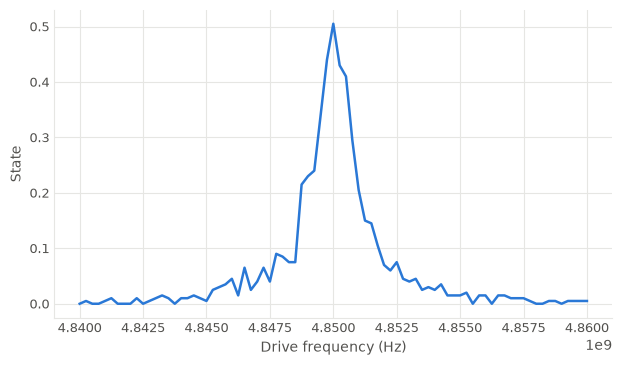

In [7]:
result.plot(m_spec, field=MF.STATE)

The x axis named itself, because `drive_freq` was declared with a `label` and a `units`. The y axis reads `State`, which is the name of the field rather than the name of the quantity, and `value=` is the one argument that fixes it.

<Axes: xlabel='Drive frequency (Hz)', ylabel='Excited-state population'>

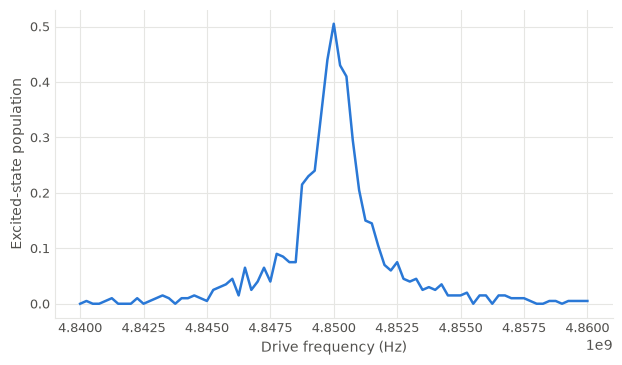

In [8]:
result.plot(m_spec, field=MF.STATE, value=Quantity("Excited-state population"))

The next call adds `coords=`, `style=` and `title=`, all three of them Part 2's and none of them new here. Two things about the figure it draws are.

A state field is one series with no name to carry, so its line comes back with matplotlib's placeholder name. The renderer draws a legend only when a figure holds two or more labelled marks, so naming that line with `ax.lines[0].set_label` is what lets a legend mix the measurement with something you added.

What you add takes its colour from a `Theme`. `Style()` defaults to `LIGHT`, whose `series` holds four categorical slots and whose `muted` is the grey the axis labels are drawn in, so an annotation stays in the palette the data was drawn with.

LIGHT.series: ('#2a78d6', '#eb6834', '#1baf7a', '#eda100')
LIGHT.muted : #52514e | Style() uses LIGHT: True


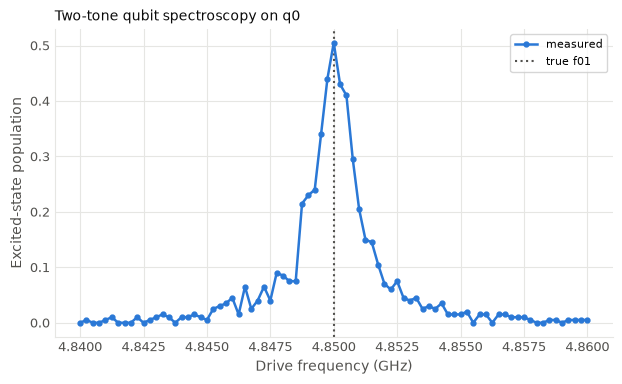

In [9]:
# Reused by every figure below. The array stays in hertz; only the drawing moves.
GHZ = Quantity(units="GHz", transform=lambda v: v / 1e9)
POPULATION = Quantity("Excited-state population")

print("LIGHT.series:", LIGHT.series)
print("LIGHT.muted :", LIGHT.muted, "| Style() uses LIGHT:", Style().theme is LIGHT)

ax = result.plot(
    m_spec,
    field=MF.STATE,
    style=Style(markers=True),  # 81 coarse points: the samples are the measurement
    coords={"drive_freq": GHZ},
    value=POPULATION,
    title="Two-tone qubit spectroscopy on q0",
)
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["q0_f01"] / 1e9, color=LIGHT.muted, linestyle=":", label="true f01")
ax.legend(fontsize=8)

### Fitting the peak

The highest point in the scan can only be as good as the step size, and the binomial scatter moves it off the right grid point often enough to matter. A fit uses every point at once and comes with an error bar you can quote.

`curve_fit` wants a starting guess for each of the four Lorentzian parameters, and three of them are read off the data: the centre from `argmax`, the height from the range, the floor from the median. The width is the one you bring yourself, and the right order of magnitude is enough. `curve_fit` is a local optimizer, so a Lorentzian started three linewidths away sees a flat landscape and stays where it was put.

$$P(f) = P_0 + \frac{A}{1 + \left(\dfrac{f - f_{01}}{\gamma}\right)^2}$$

In [10]:
def lorentzian(f, f0, height, hwhm, floor):
    """Lorentzian peak, parameterised the way a spectroscopist reads it off a plot."""
    return floor + height / (1.0 + ((f - f0) / hwhm) ** 2)


spec_freqs = pop.coords["drive_freq"].values
spec_pop = pop.values

guess = (
    spec_freqs[spec_pop.argmax()],  # centre
    spec_pop.max() - np.median(spec_pop),  # height
    1e6,  # HWHM, order of magnitude is enough
    float(np.median(spec_pop)),  # floor
)
spec_fit, spec_cov = curve_fit(lorentzian, spec_freqs, spec_pop, p0=guess)
f01_fit, height_fit, hwhm_fit, floor_fit = spec_fit
f01_sigma = float(np.sqrt(np.diag(spec_cov))[0])

print(f"argmax    : {spec_freqs[spec_pop.argmax()] / 1e9:.6f} GHz  (grid step 0.250 MHz)")
print(f"fitted    : {f01_fit / 1e9:.6f} GHz  +/- {f01_sigma / 1e6:.3f} MHz")
print(f"true      : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"error     : {(f01_fit - DEVICE['q0_f01']) / 1e6:+.3f} MHz")
print(f"linewidth : {2 * abs(hwhm_fit) / 1e6:.3f} MHz fitted vs {DEVICE['q0_linewidth'] / 1e6:.3f} MHz true")

argmax    : 4.850000 GHz  (grid step 0.250 MHz)
fitted    : 4.850038 GHz  +/- 0.016 MHz
true      : 4.850000 GHz
error     : +0.038 MHz
linewidth : 1.768 MHz fitted vs 2.000 MHz true


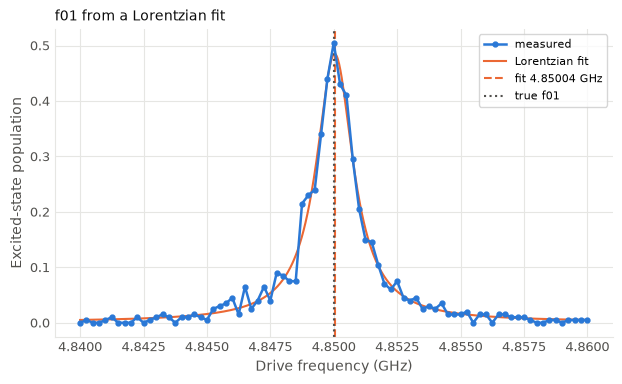

In [11]:
dense = np.linspace(spec_freqs[0], spec_freqs[-1], 800)

ax = result.plot(
    m_spec,
    field=MF.STATE,
    style=Style(markers=True),
    coords={"drive_freq": GHZ},
    value=POPULATION,
    title="f01 from a Lorentzian fit",
)
ax.lines[0].set_label("measured")
# GHZ moved the numbers, so everything added afterwards arrives in gigahertz too.
ax.plot(dense / 1e9, lorentzian(dense, *spec_fit), color=LIGHT.series[1], label="Lorentzian fit")
ax.axvline(f01_fit / 1e9, color=LIGHT.series[1], linestyle="--", label=f"fit {f01_fit / 1e9:.5f} GHz")
ax.axvline(DEVICE["q0_f01"] / 1e9, color=LIGHT.muted, linestyle=":", label="true f01")
ax.legend(fontsize=8)

## 3.2 Rabi

The frequency is known to a fraction of a linewidth. The next scan holds the pulse shape and its duration fixed, sweeps the drive amplitude, and reads the first maximum of the population as the pi pulse.

The program is one sweep and one `play`, and the new part is the pulse itself.

### A waveform with a variable in it

Part 2 put a swept variable in a readout `Square` and let a loop bind it. A drive envelope takes one the same way, and the object is worth looking at before a program is wrapped around it, because it answers some questions without a number and refuses others.

`get_duration()` answers, since the duration is a literal. `get_I()` hands back an ordinary `Gaussian` whose `amplitude` is the `Variable` rather than a float. `envelope()` is the call that needs a number, and it raises `UnassignedVariableError` until something binds one.

In [12]:
rabi = qp.QProgram(label="rabi_amplitude", description="Amplitude Rabi on q0", schema=schema)
amp = rabi.variable("amp", label="Drive amplitude", units="DAC units")

parametric = IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

print("duration    :", parametric.get_duration(), "ns")
print("I is a      :", type(parametric.get_I()).__name__, "with amplitude", repr(parametric.get_I().amplitude))
print("variables   :", sorted(v.id for v in parametric.get_I().amplitude.variables()))

try:
    parametric.get_I().envelope()
except qp.UnassignedVariableError as err:
    print("envelope    :", err)

amp.set_value(0.5)  # what the sweep does once per iteration
print("bound peak  :", round(float(parametric.get_I().envelope().max()), 4))
amp.reset()

duration    : 40 ns
I is a      : Gaussian with amplitude Variable('amp')
variables   : ['amp']
envelope    : Cannot evaluate expression Variable('amp'): unassigned variable(s) {Variable('amp')}
bound peak  : 0.4994


The `.qp` format is narrower here than the tree is. A waveform argument may be a number, a quoted string, another constructor, or a bare variable reference, but never an expression built from one. `IQDrag(amplitude=amp, ...)` writes and reads back unchanged. `IQDrag(amplitude=amp / 2, ...)` writes as `(amp / 2)` and then refuses to parse, so arithmetic on a swept variable belongs in the sweep source rather than in the constructor.

A parametric pulse also asks for less than it looks. A `Play` node reports the waveform it carries and no expression tokens at all, where `set_gain` and `set_offset` report the tokens of the expressions they hold. Part 5 is where a rack reads both kinds and says which of them it can supply.

In [13]:
sketch = qp.QProgram(label="round_trip", schema=schema)
a = sketch.variable("amp")
sketch.play(q[0].drive, IQDrag(amplitude=a, duration=40, sigma=10, beta=0.1))
sketch.set_gain(q[0].drive, a)

for node in sketch.body.elements:
    print(f"{type(node).__name__:9}", sorted(node.required_capabilities()))

text = qp.dumps(sketch)
print("\nround trips:", qp.loads(text).body == sketch.body)

expr = qp.QProgram(label="expression", schema=schema)
b = expr.variable("amp")
expr.play(q[0].drive, IQDrag(amplitude=b / 2, duration=40, sigma=10, beta=0.1))
print("written as :", next(line.strip() for line in qp.dumps(expr).splitlines() if line.startswith("  play")))
try:
    qp.loads(qp.dumps(expr))
except qp.ParseError as err:
    print("read back  :", type(err).__name__)

Play      ['op.play', 'waveform.iq', 'waveform.iq_drag']
SetGain   ['expr.variable', 'op.set_gain']

round trips: True
written as : play q[0].drive IQDrag(amplitude=(amp / 2), duration=40, sigma=10, beta=0.1)
read back  : ParseError


In [14]:
def p_rabi(bus, env):
    """Rabi oscillation in amplitude: a full pi rotation at DEVICE['q0_a_pi']."""
    return np.sin(np.pi * env["amp"] / (2 * DEVICE["q0_a_pi"])) ** 2


with rabi.average(shots=200):
    with rabi.sweep(amp, qp.Linspace(0.0, 1.0, 41)):
        rabi.set_frequency(q[0].drive, f01_fit)  # the fitted frequency, not the true one
        rabi.play(q[0].drive, parametric)
        rabi.sync()
        m_rabi = rabi.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(rabi))

#!QProgram 1.0

metadata:
  label: "rabi_amplitude"
  description: "Amplitude Rabi on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var amp label="Drive amplitude" units="DAC units"

  average 200:
    for amp in Linspace(start=0.0, stop=1.0, num=41):
      set_frequency q[0].drive 4850037623.644008
      play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



One `play` line, one variable in it, and 41 pulses at run time. The file records the sweep rather than the pulses.

dims: ('amp',) shape: (41,)
highest measured point at amplitude 0.575


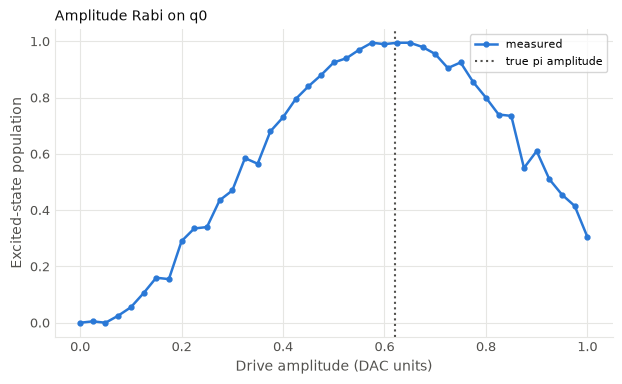

In [15]:
rabi_result = qp.simulate(rabi, model=qp.MockMeasurementModel(p_excited=p_rabi, seed=17))
rabi_data = rabi_result.get(m_rabi, field=MF.STATE)

rabi_amps = rabi_data.coords["amp"].values
rabi_pop = rabi_data.values
print("dims:", rabi_data.dims, "shape:", rabi_data.shape)
print("highest measured point at amplitude", round(float(rabi_amps[rabi_pop.argmax()]), 4))

# The amplitude axis carries no unit change, so this figure needs no coords= at all.
ax = rabi_result.plot(
    m_rabi,
    field=MF.STATE,
    style=Style(markers=True),
    value=POPULATION,
    title="Amplitude Rabi on q0",
)
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["q0_a_pi"], color=LIGHT.muted, linestyle=":", label="true pi amplitude")
ax.legend(fontsize=8)

### Fitting the pi amplitude

On this chip `p_rabi` returns exactly $\sin^2$, so the two parameters the fit returns alongside $a_\pi$, the floor $P_0$ and the contrast $C$, are the noise draw and the shot count talking.

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{2 a_\pi}\right)$$

In [16]:
def rabi_model(a, a_pi, contrast, floor):
    """Rabi in amplitude, parameterised by the pi amplitude itself."""
    return floor + contrast * np.sin(np.pi * a / (2 * a_pi)) ** 2


rabi_fit, rabi_cov = curve_fit(
    rabi_model,
    rabi_amps,
    rabi_pop,
    p0=(rabi_amps[rabi_pop.argmax()], rabi_pop.max() - rabi_pop.min(), rabi_pop.min()),
)
a_pi_fit, contrast_fit, floor_fit = rabi_fit
a_pi_sigma = float(np.sqrt(np.diag(rabi_cov))[0])

print(f"a_pi fitted : {a_pi_fit:.4f} +/- {a_pi_sigma:.4f}")
print(f"a_pi true   : {DEVICE['q0_a_pi']:.4f}")
print(f"error       : {100 * (a_pi_fit - DEVICE['q0_a_pi']) / DEVICE['q0_a_pi']:+.2f}%")
print(f"contrast    : {contrast_fit:.3f}   floor: {floor_fit:.3f}")

a_pi fitted : 0.6176 +/- 0.0022
a_pi true   : 0.6200
error       : -0.39%
contrast    : 0.998   floor: 0.006


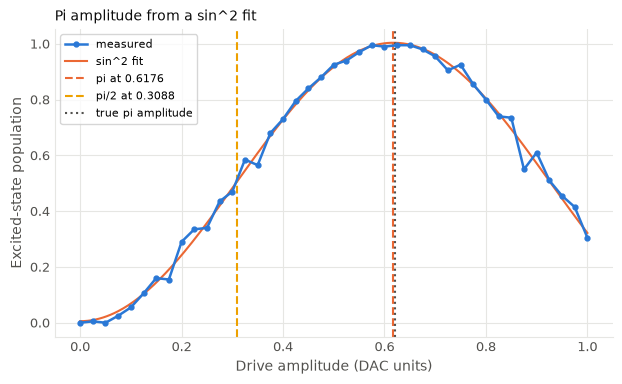

In [17]:
dense_amp = np.linspace(rabi_amps[0], rabi_amps[-1], 400)

ax = rabi_result.plot(
    m_rabi,
    field=MF.STATE,
    style=Style(markers=True),
    value=POPULATION,
    title="Pi amplitude from a sin^2 fit",
)
ax.lines[0].set_label("measured")
ax.plot(dense_amp, rabi_model(dense_amp, *rabi_fit), color=LIGHT.series[1], label="sin^2 fit")
ax.axvline(a_pi_fit, color=LIGHT.series[1], linestyle="--", label=f"pi at {a_pi_fit:.4f}")
ax.axvline(a_pi_fit / 2, color=LIGHT.series[3], linestyle="--", label=f"pi/2 at {a_pi_fit / 2:.4f}")
ax.axvline(DEVICE["q0_a_pi"], color=LIGHT.muted, linestyle=":", label="true pi amplitude")
ax.legend(fontsize=8)

### The calibrated pulses

A calibrated gate, in this stack, is a waveform object with numbers in it. `PI_PULSE` flips the qubit and `X90_PULSE` takes it to the equator, where Part 4 needs two of them for a Ramsey fringe and two around a pi pulse for an echo. The amplitude is the only thing in either object that a fit produced, rounded to four decimals and already finer than the 0.002 the fit knows it to. `beta` is 0.1 by assumption, and 3.3 is where both objects acquire names.

Halving `a_pi` for the x90 assumes the response is exactly $\sin^2$, which holds here by construction. Exercise 3.1 measures the pi/2 amplitude instead.

In [18]:
PI_PULSE = IQDrag(amplitude=round(float(a_pi_fit), 4), duration=40, sigma=10, beta=0.1)
X90_PULSE = IQDrag(amplitude=round(float(a_pi_fit) / 2, 4), duration=40, sigma=10, beta=0.1)

print("pi  :", PI_PULSE.amplitude, "over", PI_PULSE.get_duration(), "ns")
print("x90 :", X90_PULSE.amplitude, "over", X90_PULSE.get_duration(), "ns")

pi  : 0.6176 over 40 ns
x90 : 0.3088 over 40 ns


### Drawing one pulse over another

An `IQWaveform` draws on two stacked panels sharing an x axis, and `plot()` hands the `(I, Q)` pair back.

(<Axes: title={'left': 'IQDrag'}, ylabel='I'>,
 <Axes: xlabel='Time (ns)', ylabel='Q'>)

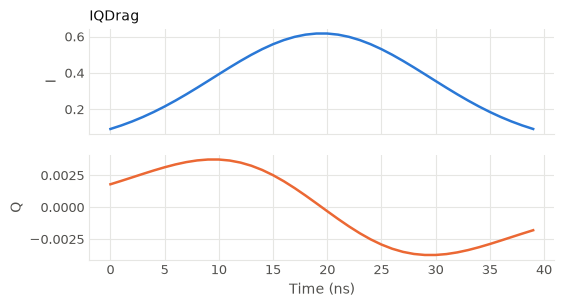

In [19]:
PI_PULSE.plot()

Hand that pair to a second call as `target=` and both pulses land on the same panels.

(<Axes: title={'left': 'IQDrag'}, ylabel='I'>,
 <Axes: xlabel='Time (ns)', ylabel='Q'>)

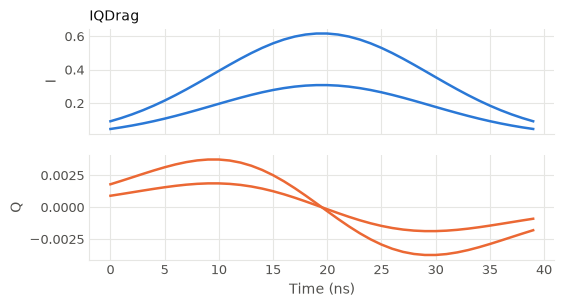

In [20]:
ax_i, ax_q = PI_PULSE.plot()
X90_PULSE.plot(target=(ax_i, ax_q))

Both pulses came out in the same two colours, and the reason is worth having straight. The palette does not advance from call to call. Each draw starts its colour counter at the slot its own figure declares, and `IQWaveform.plot` always builds I at slot 0 and Q at slot 1, so a second call repeats the first call's hues exactly. The same reset is why a second `result.plot(..., target=ax)` draws over the first in slot 0.

Moving off them means handing the second call a different palette. `Style` and `Theme` are frozen dataclasses, so `dataclasses.replace` is the ordinary way to build one, and rotating the `series` tuple by two shifts both panels together.

Text(0.0, 1.0, 'The two calibrated drive pulses')

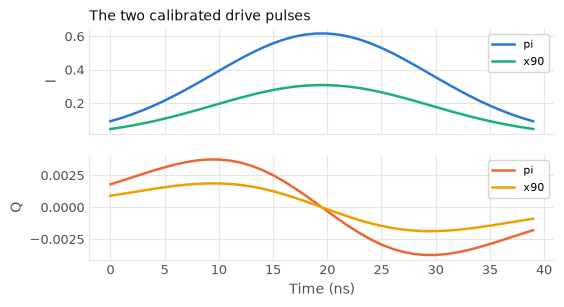

In [21]:
ax_i, ax_q = PI_PULSE.plot()
rotated = Style(theme=replace(LIGHT, series=LIGHT.series[2:] + LIGHT.series[:2]))
X90_PULSE.plot(target=(ax_i, ax_q), style=rotated)

for panel in (ax_i, ax_q):
    for line, name in zip(panel.lines, ("pi", "x90"), strict=True):
        line.set_label(name)
    panel.legend(fontsize=8)
ax_i.set_title("The two calibrated drive pulses", loc="left", fontsize=10, pad=6)

### 🧩 Exercise 3.1

Fit the x90 amplitude rather than halving the pi amplitude. Refit **only the rising branch** of the Rabi curve (everything up to the maximum) with the model written in terms of $a_{90}$:

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{4 a_{90}}\right)$$

Print the fitted $a_{90}$, the halved $a_\pi$, and the true $a_\pi / 2$ from `DEVICE`. You have `rabi_amps`, `rabi_pop`, `a_pi_fit`, `contrast_fit`, and `floor_fit` in scope.

In [ ]:
# TODO: fit the pi/2 amplitude from the rising branch of the Rabi curve.
# 1) rising = slice(0, int(rabi_pop.argmax()) + 1)
# 2) def x90_model(a, a_90, contrast, floor): return floor + contrast * sin(pi * a / (4 * a_90))**2
# 3) curve_fit(x90_model, rabi_amps[rising], rabi_pop[rising], p0=(a_pi_fit / 2, contrast_fit, floor_fit))
# 4) print the fitted a_90, a_pi_fit / 2, and DEVICE["q0_a_pi"] / 2 side by side.

## 3.3 The waveform library

The Rabi program has `IQDrag(amplitude=amp, ...)` written into it, and that was right, because the shape of the pulse was the experiment. Every program after it wants the pi pulse, whatever its amplitude happens to be today.

Part 1 left that hole with a string alias and filled it with a plain dict. The dict still works, and `with_waveforms` promotes one through `qp.WaveformLibrary.from_mapping`, which registers every key at a single tier that matches every bus. That flat namespace is the limit of a dict: it has no way to say that `"pi"` means one amplitude on `q[0]` and another on `q[1]`.

In [23]:
seq = qp.QProgram(label="pi_then_read", description="Flip q0 and read it out", schema=schema)

with seq.average(shots=200):
    seq.play(q[0].drive, "pi")
    seq.sync()
    m_seq = seq.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(seq).split("body:")[1])
print("a dict binds it:", next(line.strip() for line in qp.dumps(seq.with_waveforms({"pi": PI_PULSE})).splitlines() if line.strip().startswith("play")))


  average 200:
    play q[0].drive "pi"
    sync
    measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]

a dict binds it: play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)


### One name, three tiers

`qp.WaveformLibrary` is the same argument to the same call with a resolution order behind it. `set(name, waveform)` with no keywords registers the global tier, the one a dict gives you, and `get(bus, name)` asks what a bus would receive with no program in the way.

In [24]:
flat = qp.WaveformLibrary()
flat.set("weights", WEIGHTS)  # no keywords: the global tier

print("repr           :", repr(flat), "| bool() of an empty one:", bool(qp.WaveformLibrary()))
print("on q[0].drive  :", flat.get(q[0].drive, "weights") is WEIGHTS)
print("on q[5].readout:", flat.get(q[5].readout, "weights") is WEIGHTS)
print("a name it lacks:", flat.get(q[0].drive, "pi"))  # a miss returns None, never an exception

repr           : WaveformLibrary(1 entries) | bool() of an empty one: False
on q[0].drive  : True
on q[5].readout: True
a name it lacks: None


Two more keyword combinations open the tiers above it, and nothing else is accepted.

| Tier | How you register it | The key it stores | Matches |
|---|---|---|---|
| exact | `element=`, `idx=`, `kind=` | `(element, idx, kind, name)` | one bus |
| family | `element=`, `kind=` | `(element, None, kind, name)` | every index of that element and kind |
| global | no keywords | `(None, None, None, name)` | every bus |

`get(bus, name)` tries those three keys in that order and returns the first hit, so exact beats family and family beats global. Reaching the top two needs the `element`, `idx` and `kind` a `BusRef` carries, so a bus written as a plain string reaches the global tier and nothing above it. Part 5 leans on the same property when it renames every bus on a rack and the library follows along.

In [25]:
tiers = qp.WaveformLibrary()
tiers.set("probe", Square(amplitude=0.11, duration=100))  # global
tiers.set("probe", Square(amplitude=0.22, duration=100), element="q", kind="drive")  # family
tiers.set("probe", Square(amplitude=0.33, duration=100), element="q", idx=0, kind="drive")  # exact

for bus, tier in ((q[0].drive, "exact wins"), (q[1].drive, "no exact, family wins"), (q[0].readout, "neither, global")):
    print(f"{bus:12} -> {tiers.get(bus, 'probe').amplitude:.2f}   ({tier})")
print(f"{'q0/drive':12} -> {tiers.get('q0/drive', 'probe').amplitude:.2f}   (a plain string reaches the global tier only)")

try:
    tiers.set("probe", Square(amplitude=0.44, duration=100), element="q", idx=0)
except qp.ValidationError as exc:
    print("\nhalf a tier:", exc)

q0/drive     -> 0.33   (exact wins)
q1/drive     -> 0.22   (no exact, family wins)
q0/readout   -> 0.11   (neither, global)
q0/drive     -> 0.11   (a plain string reaches the global tier only)

half a tier: WaveformLibrary.set: specify (element, idx, kind) for an exact entry, (element, kind) for a family default, or none of them for a global entry; got element='q', idx=0, kind=None


### The library this chip runs on

Drive pulses go in the exact tier, readout tones are usually a family default, and integration weights are global. The scope is the whole choice, and `dumps` writes the entries back in the order they were registered.

In [26]:
library = qp.WaveformLibrary()
library.set("pi", PI_PULSE, element="q", idx=0, kind="drive")  # exact: this qubit only
library.set("x90", X90_PULSE, element="q", idx=0, kind="drive")
library.set("readout", READOUT_PULSE, element="q", kind="readout")  # family: any q readout
library.set("weights", WEIGHTS)  # global

bound = seq.with_waveforms(library)

print(qp.dumps(bound).split("body:")[1])
print("the original still holds its aliases:", seq.body != bound.body)


  average 200:
    play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
    sync
    measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state"]

the original still holds its aliases: True


Give the neighbouring qubit its own exact entry and one alias resolves to two different pulses inside one program, while `q[2]` gets nothing at any tier. An unmatched name survives the bind as the string it was, silently, and `body.waveforms()` is how you ask a program what it still needs. On the reference platform an unbound alias costs nothing, since the executor models measurements and never reads a pulse. A real backend has to turn the name into samples, and `qp.WaveformResolutionError` is the error it is expected to raise.

In [27]:
library.set("pi", IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1),
            element="q", idx=1, kind="drive")  # exact: a standing calibration, not measured here

three = qp.QProgram(label="three_buses", schema=schema)
for i in (0, 1, 2):
    three.play(q[i].drive, "pi")
    three.measure(q[i].readout, "readout", "weights", fields=(MF.STATE,))

three_bound = three.with_waveforms(library)
for line in qp.dumps(three_bound).splitlines():
    if line.strip().startswith("play"):
        print(line.strip())

readouts = {id(node.waveform) for node in three_bound.body.walk() if isinstance(node, Measure)}
print("\none family entry served all three readouts:", len(readouts) == 1)
print("still unbound:", sorted(name for name in three_bound.body.waveforms() if isinstance(name, str)))

play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
play q[1].drive IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1)
play q[2].drive "pi"

one family entry served all three readouts: True
still unbound: ['pi']


### The `.wfl` file

The library has a text format of its own, and it is legible as a picture of the tiers. The coordinate between the quoted name and the `=` is the tier: `q[0].drive` is exact, `q[*].readout` is the family glob, and nothing at all is global. The waveform on the right is the same constructor syntax `.qp` uses.

The program is the experiment you designed and the library is the state of the fridge when you ran it. The two change at different rates, which is why they are two files, and a lab that keeps them in one cannot tell whether two runs were the same experiment.

In [28]:
out = Path("out")
out.mkdir(exist_ok=True)
wfl_path = out / "q0_calibration.wfl"

print(library.dumps())

library.save(wfl_path)
print("round trips:", qp.WaveformLibrary.load(wfl_path).dumps() == library.dumps())

#!WaveformLibrary 1.0
"pi" q[0].drive = IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
"x90" q[0].drive = IQDrag(amplitude=0.3088, duration=40, sigma=10, beta=0.1)
"readout" q[*].readout = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
"weights" = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))
"pi" q[1].drive = IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1)

round trips: True


Because the library is a file, one unchanged program on disk gives different pulses against different calibrations. Below, `seq` binds to a stale library and to the current one.

A library holds concrete waveforms only. Store the parametric `IQDrag` from 3.2 and `set` accepts it, `get` hands it back, and `dumps` refuses, since there is no spelling for a variable in a `.wfl`.

In [29]:
def play_line(program):
    """Pull the single `play` statement out of a program's .qp text."""
    return next(line.strip() for line in qp.dumps(program).splitlines() if line.strip().startswith("play"))


stale = qp.WaveformLibrary()
stale.set("pi", IQDrag(amplitude=0.50, duration=40, sigma=10, beta=0.1), element="q", idx=0, kind="drive")

print("bound to the stale library  :", play_line(seq.with_waveforms(stale)))
print("bound to the current library:", play_line(bound))
print("the program on disk         :", play_line(seq))

symbolic = qp.WaveformLibrary()
symbolic.set("pi", parametric)
print("\nset and get are happy:", type(symbolic.get(q[0].drive, "pi")).__name__)
try:
    symbolic.dumps()
except qp.SerializationError as exc:
    print("dumps is not:", exc)

bound to the stale library  : play q[0].drive IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
bound to the current library: play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
the program on disk         : play q[0].drive "pi"

set and get are happy: IQDrag
dumps is not: cannot serialize the waveform stored under name 'pi': a WaveformLibrary must hold concrete waveforms (no Variables / symbolic parameters). Underlying error: 'amp'


## 3.4 The flux arc

A flux-tunable transmon has a third line. A DC bias moves `f01` along a square root of a cosine,

$$f_{01}(V) = f_{\max} \sqrt{\left| \cos \frac{\pi (V - V_0)}{V_\Phi} \right|}$$

and all three parameters are measured rather than looked up, because the volts your DAC puts out reach the loop through a mutual inductance nobody wrote down. $V_0$ is the flat top, and every coherence number in Part 4 was measured there.

Mapping the arc means repeating the scan of 3.1 at a series of biases, which brings in a second bus kind, a new operation, and a two-dimensional result.

### A third bus

`BusSchema.flux_tunable_transmon()` is the same `q` accessor with `flux` added. Two metadata fields carry the whole difference. `channel` is `single` rather than `IQ`, so this line takes a `Square` where the drive takes an `IQPair`, and `acquires` is `False`, so `measure` on it is refused. Both checks fire on the line that made the mistake.

In [30]:
flux_schema = BusSchema.flux_tunable_transmon()
qf = flux_schema.q

for bus in (qf[0].drive, qf[0].readout, qf[0].flux):
    print(f"{bus:12} channel={bus.channel:6} acquires={bus.acquires}")

mistakes = qp.QProgram(label="flux_mistakes", schema=flux_schema)
try:
    mistakes.play(qf[0].flux, IQPair(I=Square(0.1, 40), Q=Square(0.0, 40)))
except qp.ValidationError as exc:
    print("\nIQ pair on a single channel:", exc)

try:
    mistakes.measure(qf[0].flux, "readout", "weights")
except qp.ValidationError as exc:
    print("\nmeasure without an ADC     :", exc)

q0/drive     channel=IQ     acquires=False
q0/readout   channel=IQ     acquires=True
q0/flux      channel=single acquires=False

IQ pair on a single channel: Bus 'q0/flux' is a single channel but received an IQWaveform (IQPair). Use a single-channel Waveform (e.g. Square, FlatTop) instead.

measure without an ADC     : Bus 'q0/flux' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


Six presets ship, three families each with a `_coupled` variant that adds an element `c` for the tunable couplers. A coupler is usually indexed by the pair it sits between, and `c[0, 1].flux` resolves to one bus whose `idx` is the tuple `(0, 1)`, which the naming pattern joins with an underscore.

When none of the six fits, `add_element` on a bare `BusSchema()` registers an element at run time. You get the same `BusRef`s with the same metadata and the same `.qp` round trip, and you give up the typed accessors, so a misspelled bus kind becomes an `AttributeError` at run time rather than something an editor catches.

In [31]:
for name in ("transmon", "transmon_coupled", "flux_tunable_transmon",
             "flux_tunable_transmon_coupled", "fluxonium", "fluxonium_coupled"):
    preset = getattr(BusSchema, name)()
    shape = {element: sorted(spec.buses) for element, spec in preset.elements.items()}
    print(f"{name:30}", shape)

coupled = BusSchema.flux_tunable_transmon_coupled()
print("\ncoupler bus:", coupled.c[0, 1].flux, "| idx:", coupled.c[0, 1].flux.idx)

custom = BusSchema()
custom.add_element("resonator", {"probe": ("IQ", True), "bias": ("single", False)})
print("registered at run time:", custom.resonator[3].probe, "| acquires:", custom.resonator[3].probe.acquires)
try:
    custom.resonator[3].drive
except AttributeError as exc:
    print("and unchecked until it runs:", exc)

transmon                       {'q': ['drive', 'readout']}
transmon_coupled               {'q': ['drive', 'readout'], 'c': ['flux']}
flux_tunable_transmon          {'q': ['drive', 'flux', 'readout']}
flux_tunable_transmon_coupled  {'q': ['drive', 'flux', 'readout'], 'c': ['flux']}
fluxonium                      {'q': ['drive', 'flux_x', 'flux_z', 'readout']}
fluxonium_coupled              {'q': ['drive', 'flux_x', 'flux_z', 'readout'], 'c': ['flux']}

coupler bus: c0_1/flux | idx: (0, 1)
registered at run time: resonator3/probe | acquires: True
and unchecked until it runs: 'resonator' has no bus 'drive'. Available: probe, bias


### `set_offset`

`set_offset(bus, offset_path0, offset_path1=None)` is the operation Part 1's table held over for this part. It writes a level and occupies no time on the bus, one argument per path: path 0 is the only path on a single-channel bus and I on an IQ bus, and path 1 is Q. Passing `None` leaves path 1 as it was rather than zeroing it, and the `.qp` writer omits it entirely.

It is also the one bus-carrying operation that does not compare its second path against the channel, because the channel check is a waveform check and only `play` and `measure` carry waveforms. A second path on a single-channel bus passes the builder, `qp.dumps` and `qp.validate` without a word.

Three operations on the same bus are easy to confuse, and the text they emit tells them apart. `set_offset` has two value slots and no duration, `set_gain` has one value slot and scales whatever is played, and `play` is the only one of the three that puts a shape on the timeline.

In [32]:
knobs = qp.QProgram(label="three_knobs", schema=flux_schema)
level = knobs.variable("level", label="Flux bias", units="V")

knobs.set_offset(qf[0].flux, level)
knobs.set_gain(qf[0].flux, level)
knobs.play(qf[0].flux, Square(amplitude=level, duration=100))
knobs.set_offset(qf[0].flux, 0.1, 0.2)  # a second path on a one-path bus: accepted in silence

print(qp.dumps(knobs).split("body:")[1])
for node in knobs.body.elements:
    print(f"{type(node).__name__:10}", sorted(node.required_capabilities()))


  var level label="Flux bias" units="V"

  set_offset q[0].flux level
  set_gain q[0].flux level
  play q[0].flux Square(amplitude=level, duration=100)
  set_offset q[0].flux 0.1 offset_path1=0.2

SetOffset  ['expr.variable', 'op.set_offset']
SetGain    ['expr.variable', 'op.set_gain']
Play       ['op.play', 'waveform.single', 'waveform.square']
SetOffset  ['op.set_offset']


### The survey

The grid below is coarse in both directions, because a two-dimensional map has to show a ridge rather than measure a population to three digits. The model widens the line to match, since a survey is run at a power that broadens the transition well past the frequency step.

The reference executor treats `SetOffset` as a no-op, forcing the expressions inside it and doing nothing else. A model's `env` holds the swept variables keyed by id, plus the platform parameter store keyed as `"bus.parameter"`, and a DC offset appears in neither. `p_arc` reads `env["bias"]` because `bias` is a swept variable in scope, not because a level was written anywhere.

In [33]:
def f01_of_bias(bias_v):
    """Where the qubit sits at a given flux bias. Maximum at DEVICE['flux_offset']."""
    phase = np.pi * (bias_v - DEVICE["flux_offset"]) / DEVICE["flux_period"]
    return DEVICE["q0_f01"] * np.sqrt(np.abs(np.cos(phase)))


POWER_BROADENED = 20e6  # Hz FWHM: a survey line, ten times the 2 MHz of the low-power scan


def p_arc(bus, env):
    """Spectroscopy peak that follows the arc as the bias steps."""
    hwhm = POWER_BROADENED / 2
    return 0.45 / (1.0 + ((env["arc_freq"] - f01_of_bias(env["bias"])) / hwhm) ** 2)


for bias_v in (-0.15, 0.05, 0.25):
    print(f"bias {bias_v:+.2f} V -> f01 {f01_of_bias(bias_v) / 1e9:.4f} GHz")

bias -0.15 V -> f01 4.3624 GHz
bias +0.05 V -> f01 4.8500 GHz
bias +0.25 V -> f01 4.3624 GHz


In [34]:
arc = qp.QProgram(label="flux_arc", description="f01 against flux bias on q0", schema=flux_schema)
bias = arc.variable("bias", label="Flux bias", units="V")
arc_freq = arc.variable("arc_freq", label="Drive frequency", units="Hz")

with arc.average(shots=50):
    with arc.sweep(bias, qp.Linspace(-0.15, 0.25, 25)):
        arc.set_offset(qf[0].flux, bias)  # a level, not a pulse
        with arc.sweep(arc_freq, qp.Linspace(4.30e9, 4.90e9, 61)):
            arc.set_frequency(qf[0].drive, arc_freq)
            arc.play(qf[0].drive, SATURATION)
            arc.sync()
            m_arc = arc.measure(qf[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(arc))

#!QProgram 1.0

metadata:
  label: "flux_arc"
  description: "f01 against flux bias on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var bias label="Flux bias" units="V"
  var arc_freq label="Drive frequency" units="Hz"

  average 50:
    for bias in Linspace(start=-0.15, stop=0.25, num=25):
      set_offset q[0].flux bias
      for arc_freq in Linspace(start=4300000000.0, stop=4900000000.0, num=61):
        set_frequency q[0].drive arc_freq
        play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
        sync
        measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



Two nested sweeps and one `set_offset` between them are the whole scan. `average` sits outside both, and the reference executor runs shots as its outermost loop, so the DC write happens once per bias point per shot rather than once per bias point. Part 5 takes a one-dimensional slice of this program, shows `qp.optimize` hoisting that write out of the average, and explains why a nested sweep like this one falls outside the pattern the rewrite matches.

In [35]:
arc_result = qp.simulate(arc, model=qp.MockMeasurementModel(p_excited=p_arc, seed=23))
arc_data = arc_result.get(m_arc, field=MF.STATE)

biases = arc_data.coords["bias"].values
arc_freqs = arc_data.coords["arc_freq"].values
arc_grid = arc_data.values
ridge = arc_freqs[arc_grid.argmax(axis=1)]  # brightest frequency at each bias

print("dims:", arc_data.dims, "shape:", arc_data.shape)
print("bias step:", round(float(biases[1] - biases[0]), 4), "V")
print("frequency step:", round(float(arc_freqs[1] - arc_freqs[0]) / 1e6, 2), "MHz")
print("ridge (GHz):", np.round(ridge / 1e9, 3))

dims: ('bias', 'arc_freq') shape: (25, 61)
bias step: 0.0167 V
frequency step: 10.0 MHz
ridge (GHz): [4.36 4.44 4.52 4.58 4.64 4.69 4.73 4.77 4.8  4.82 4.84 4.84 4.85 4.85
 4.84 4.82 4.8  4.77 4.73 4.69 4.64 4.58 4.51 4.44 4.36]


Two swept dimensions make a heatmap, and `field=` reaches it exactly as it reached the line.

<Axes: xlabel='Drive frequency (Hz)', ylabel='Flux bias (V)'>

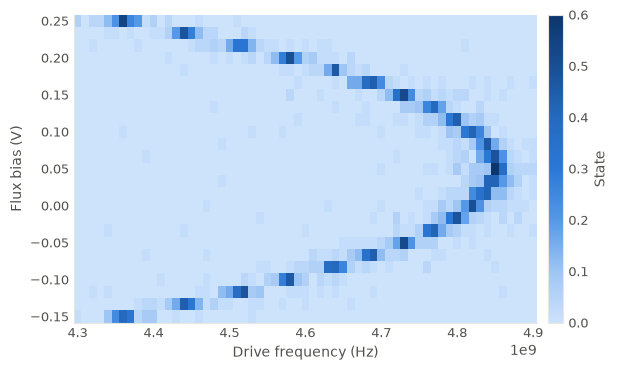

In [36]:
arc_result.plot(m_arc, field=MF.STATE)

The bare call put the inner sweep along x, matching the loop nesting. `x=` moves the bias to the bottom the way a bring-up log draws it, and naming one axis settles the other. On a heatmap `value=` labels the colour bar rather than an axis, and `coords=` may restate both axes at once. The two annotations take warm slots from the same palette, because the theme's ramp is blue and they have to stay legible over the map.

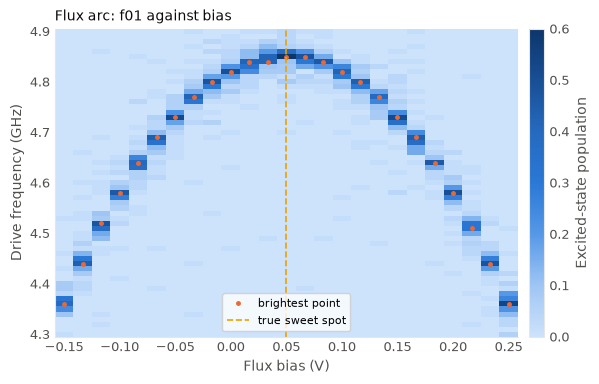

In [37]:
ax = arc_result.plot(
    m_arc,
    field=MF.STATE,
    x="bias",  # bias along the bottom, frequency up the side
    coords={"arc_freq": GHZ},
    value=POPULATION,
    title="Flux arc: f01 against bias",
)
ax.plot(biases, ridge / 1e9, ".", color=LIGHT.series[1], markersize=5, label="brightest point")
ax.axvline(DEVICE["flux_offset"], color=LIGHT.series[3], linestyle="--", linewidth=1.2, label="true sweet spot")
ax.legend(fontsize=8, loc="lower center")

### Fitting the arc

The ridge is quantised to the frequency grid, so no point in it is better than one step, and the fit still comes out far better than any of its inputs. The curve on each side of the maximum votes on where the middle is, so the symmetry pins $V_0$ much more tightly than the bias step suggests.

The arc is flat at the top and steep at the edges, so a bad guess for the period can land the fit a whole period away. Start $V_0$ at the brightest column and $V_\Phi$ at twice the bias span you scanned.

In [38]:
def arc_model(bias_v, f_max, offset, period):
    """The transmon flux arc: cosine under a square root."""
    return f_max * np.sqrt(np.abs(np.cos(np.pi * (bias_v - offset) / period)))


arc_fit, arc_cov = curve_fit(
    arc_model,
    biases,
    ridge,
    p0=(ridge.max(), float(biases[ridge.argmax()]), 2 * (biases[-1] - biases[0])),
)
f_max_fit, offset_fit, period_fit = arc_fit
arc_sigma = np.sqrt(np.diag(arc_cov))

print(f"f_max  fitted: {f_max_fit / 1e9:.6f} GHz +/- {arc_sigma[0] / 1e6:.3f} MHz")
print(f"f_max  true  : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"offset fitted: {offset_fit:+.4f} V +/- {arc_sigma[1]:.4f} V")
print(f"offset true  : {DEVICE['flux_offset']:+.4f} V   (bias step was 0.0167 V)")
print(f"period fitted: {period_fit:.4f} V +/- {arc_sigma[2]:.4f} V")
print(f"period true  : {DEVICE['flux_period']:.4f} V")

f_max  fitted: 4.852144 GHz +/- 0.912 MHz
f_max  true  : 4.850000 GHz
offset fitted: +0.0498 V +/- 0.0002 V
offset true  : +0.0500 V   (bias step was 0.0167 V)
period fitted: 0.9978 V +/- 0.0018 V
period true  : 1.0000 V


The fitted arc is the one figure here that `result.plot` cannot draw, and the reason is the general rule. A result knows its dimensions, its coordinates and the units on them, so it can size a figure and label both axes. A curve computed from three fitted parameters is two numpy arrays, and nothing about them says what they mean.

So this panel is built by hand, and `DEFAULT_SIZE`, the size `result.plot` gives a figure, is imported to keep it the same shape as its neighbours. `Style().color(i)` reaches the same series slots without going through a theme.

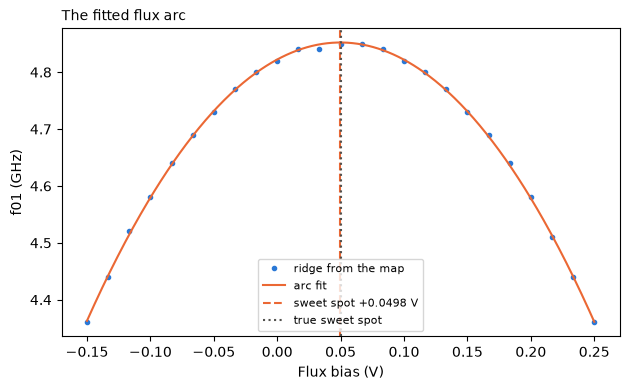

In [39]:
dense_bias = np.linspace(biases[0], biases[-1], 400)

# No result to ask, so the figure, the size, and both axis labels are all typed out here.
fig, ax = plt.subplots(figsize=DEFAULT_SIZE)
ax.plot(biases, ridge / 1e9, ".", color=Style().color(0), label="ridge from the map")
ax.plot(dense_bias, arc_model(dense_bias, *arc_fit) / 1e9, color=Style().color(1), label="arc fit")
ax.axvline(offset_fit, color=Style().color(1), linestyle="--", label=f"sweet spot {offset_fit:+.4f} V")
ax.axvline(DEVICE["flux_offset"], color=LIGHT.muted, linestyle=":", label="true sweet spot")
ax.set_xlabel("Flux bias (V)")
ax.set_ylabel("f01 (GHz)")
ax.set_title("The fitted flux arc", loc="left", fontsize=10, pad=6)
ax.legend(fontsize=8)

### Parking the qubit

Inverting the fitted model turns the measurement into a setting. `arccos` returns one value and the arc is symmetric about the sweet spot, so two biases give any frequency below $f_{\max}$, and which one you want depends on the neighbours and couplers you are trying to stay away from.

$$V = V_0 + \frac{V_\Phi}{\pi} \arccos\!\left( \left( \frac{f_{\text{target}}}{f_{\max}} \right)^{2} \right)$$

The number that comes out is a `set_offset` argument, which closes the loop that 3.1 opened: a scan produced a value, and the value goes back into a program as a literal.

In [40]:
f_target = 4.70e9
step = (period_fit / np.pi) * np.arccos((f_target / f_max_fit) ** 2)

for side, bias_solution in (("above the sweet spot", offset_fit + step), ("below", offset_fit - step)):
    print(f"{side:>20}: bias {bias_solution:+.4f} V")
    print(f"{'true device gives':>20}: {f01_of_bias(bias_solution) / 1e9:.6f} GHz")
    print(f"{'miss':>20}: {(f01_of_bias(bias_solution) - f_target) / 1e6:+.3f} MHz")

park = qp.QProgram(label="park_q0", description=f"Hold q0 at {f_target / 1e9:.2f} GHz", schema=flux_schema)
park.set_offset(qf[0].flux, round(float(offset_fit + step), 4))
park.set_frequency(qf[0].drive, f_target)

print()
print(qp.dumps(park).split("body:")[1])

above the sweet spot: bias +0.1620 V
   true device gives: 4.699046 GHz
                miss: -0.954 MHz
               below: bias -0.0624 V
   true device gives: 4.698127 GHz
                miss: -1.873 MHz


  set_offset q[0].flux 0.162
  set_frequency q[0].drive 4700000000.0



### Where each sweep runs

`set_offset` contributes the capability token `op.set_offset`, and a bus-scoped token is checked against the profile of the bus the operation touches. On a rack whose flux line has no real-time engine, that token sits in the bus's host-side half and takes every loop containing it along.

Nothing in the flux arc program said which of its two sweeps is the host-side one, and nothing should have. Part 5 hands that program to a platform descriptor and prints where each loop landed.

## Recap

- **`fields=(MF.STATE,)` replaces the default field tuple**, so `get` and `plot` both need `field=` spelled out, a bare `get` raises, and a state array refuses `channels=` because it has no `IQ` dimension.
- **`result.plot` takes `field=` as its third positional**, the same one `get` takes, and everything else was Part 2's: `value=` names the measured quantity, `coords=` restates an axis, `x=` picks the heatmap axis, and the `Axes` that comes back carries the fits.
- **A waveform constructor holds a `Variable`.** `IQDrag(amplitude=amp, ...)` is one parametric pulse, `envelope()` raises until a loop binds it, and only a bare variable reference survives the `.qp` round trip.
- **`WaveformLibrary` resolves a name per bus**, exact then family then global, with `get(bus, name)` returning the first hit or `None`. A plain dict is the global tier alone. The entries live in a `.wfl` file, apart from the program on purpose.
- **`BusSchema` ships six presets**, and `flux_tunable_transmon` adds a single-channel `flux` bus with no ADC. `add_element` registers one at run time when none of the six fits.
- **`set_offset(bus, offset_path0, offset_path1=None)`** writes a level rather than playing a shape, takes an expression like every other numeric argument, and is the one operation that does not check its second path against the channel.

## Next

**Part 4, coherence and feedback.** T1, Ramsey, and echo, built out of reusable pulse fragments, then single-shot readout and active reset with a real conditional on a measured state.